# RFM Segmentation and Retention Strategy

Introduction

In Part 1, the analysis focused on understanding customer churn patterns and identifying factors that may influence customer retention. The next step is to segment customers based on their purchasing behaviour and engagement levels so that retention efforts can be targeted more effectively.

This section uses RFM (Recency, Frequency and Monetary) analysis to group customers according to how recently they purchased, how often they purchase, and how much they spend. Additional behavioural indicators such as website activity and marketing engagement are also considered to develop a more complete view of customer value and risk.

The goal is to identify meaningful customer segments, recommend suitable retention actions for each group, and determine where a limited marketing budget should be allocated to achieve the greatest impact.

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

In [27]:
customers = pd.read_csv("customers.csv")
orders = pd.read_csv("orders.csv")
tickets = pd.read_csv("support_tickets.csv")
web = pd.read_csv("web_events_snapshot.csv")

print("Customers:", customers.shape)
print("Orders:", orders.shape)
print("Tickets:", tickets.shape)
print("Web:", web.shape)

Customers: (2400, 9)
Orders: (10009, 10)
Tickets: (1921, 8)
Web: (2400, 10)


In [28]:
import os
print(os.listdir())

['.config', 'support_tickets.csv', 'retention_strategy.md', 'orders.csv', 'segments.csv', 'web_events_snapshot.csv', 'customers.csv', 'sample_data']


In [29]:
print(orders.columns.tolist())

['order_id', 'customer_id', 'order_date', 'category', 'quantity', 'gross_amount', 'discount_pct', 'delivery_days', 'returned', 'rating']


In [30]:
orders['order_date'] = pd.to_datetime(orders['order_date'])

snapshot_date = orders['order_date'].max() + pd.Timedelta(days=1)

rfm = orders.groupby('customer_id').agg({
    'order_date': lambda x: (snapshot_date - x.max()).days,
    'order_id': 'count',
    'gross_amount': 'sum'
}).reset_index()

rfm.columns = [
    'customer_id',
    'Recency',
    'Frequency',
    'Monetary'
]

rfm.head()

,customer_id,Recency,Frequency,Monetary
0,CUST00001,168,6,2955.57
1,CUST00002,35,3,1713.10
2,CUST00003,232,1,649.98
3,CUST00004,192,1,1604.04
4,CUST00005,11,6,3910.43


In [31]:
rfm['R_score'] = pd.qcut(
    rfm['Recency'],
    5,
    labels=[5,4,3,2,1]
)

rfm['F_score'] = pd.qcut(
    rfm['Frequency'].rank(method='first'),
    5,
    labels=[1,2,3,4,5]
)

rfm['M_score'] = pd.qcut(
    rfm['Monetary'],
    5,
    labels=[1,2,3,4,5]
)

rfm.head()

,customer_id,Recency,Frequency,Monetary,R_score,F_score,M_score
0,CUST00001,168,6,2955.57,2,4,3
1,CUST00002,35,3,1713.10,4,2,2
2,CUST00003,232,1,649.98,1,1,1
3,CUST00004,192,1,1604.04,2,1,2
4,CUST00005,11,6,3910.43,5,4,4


In [32]:
rfm.head()

,customer_id,Recency,Frequency,Monetary,R_score,F_score,M_score
0,CUST00001,168,6,2955.57,2,4,3
1,CUST00002,35,3,1713.10,4,2,2
2,CUST00003,232,1,649.98,1,1,1
3,CUST00004,192,1,1604.04,2,1,2
4,CUST00005,11,6,3910.43,5,4,4


# Customer Segmentation
The RFM scores were used to group customers into meaningful business segments. Rather than treating all customers the same, segmentation helps identify high-value customers, customers showing signs of churn, and customers with growth potential.

Five customer segments were created based on Recency, Frequency, and Monetary scores:

Champions
Loyal Customers
Potential Loyalists
At Risk Customers
Dormant Customers

These segments will later be combined with behavioural signals such as website activity and support interactions to support retention planning.

In [33]:
def segment_customer(row):

    if row['R_score'] >= 4 and row['F_score'] >= 4 and row['M_score'] >= 4:
        return 'Champions'

    elif row['R_score'] >= 3 and row['F_score'] >= 3:
        return 'Loyal Customers'

    elif row['R_score'] >= 4:
        return 'Potential Loyalists'

    elif row['R_score'] <= 2 and row['F_score'] >= 3:
        return 'At Risk'

    else:
        return 'Dormant'


rfm['segment_name'] = rfm.apply(segment_customer, axis=1)

rfm['segment_name'].value_counts()

,count
segment_name,
Dormant,727
Loyal Customers,577
Champions,440
At Risk,423
Potential Loyalists,233


# Segment Summary
The customer base is distributed across five segments. Dormant customers form the largest segment, indicating that a significant portion of customers have not purchased recently or have low purchase activity. Loyal Customers and Champions together represent a valuable customer group that should be retained through loyalty-focused initiatives. The At Risk segment requires targeted retention efforts, while Potential Loyalists represent an opportunity for future growth through personalized engagement.

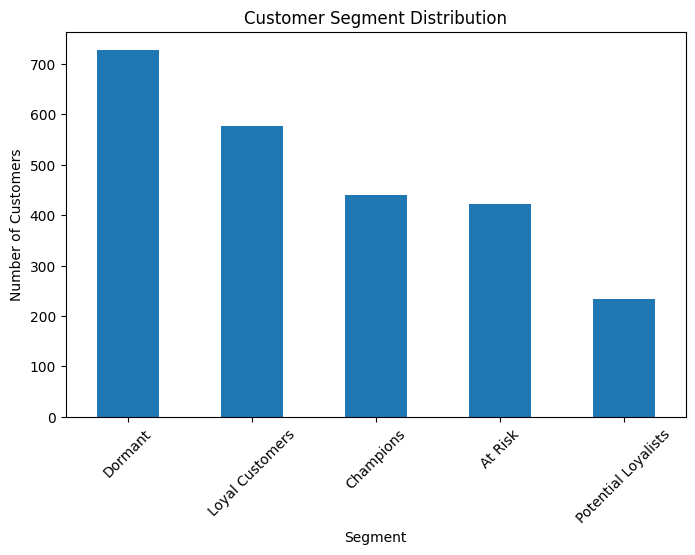

In [34]:
segment_counts = rfm['segment_name'].value_counts()

plt.figure(figsize=(8,5))

segment_counts.plot(kind='bar')

plt.title('Customer Segment Distribution')
plt.xlabel('Segment')
plt.ylabel('Number of Customers')

plt.xticks(rotation=45)

plt.show()

# Additional Behavioural Signals
RFM metrics capture purchasing behaviour, but customer engagement is influenced by other factors as well. To improve segmentation quality, website activity and customer support interactions were incorporated into the analysis. These signals provide additional context about customer engagement and potential churn risk.

In [35]:
web = pd.read_csv("web_events_snapshot.csv")
web.head()

,customer_id,snapshot_date,sessions_30d,product_views_30d,cart_adds_30d,wishlist_adds_30d,abandoned_carts_30d,email_opens_30d,campaign_clicks_30d,last_visit_days_ago
0,CUST00001,2025-09-30,1,4,0,0,0,2,0,20
1,CUST00002,2025-09-30,8,31,4,2,3,0,0,0
2,CUST00003,2025-09-30,1,3,0,0,0,0,0,26
3,CUST00004,2025-09-30,1,6,0,0,0,0,0,14
4,CUST00005,2025-09-30,18,95,4,1,1,3,1,9


In [36]:
print(web.columns.tolist())

['customer_id', 'snapshot_date', 'sessions_30d', 'product_views_30d', 'cart_adds_30d', 'wishlist_adds_30d', 'abandoned_carts_30d', 'email_opens_30d', 'campaign_clicks_30d', 'last_visit_days_ago']


# Website Engagement Analysis
Website activity was incorporated as an additional behavioural signal. Customers with higher session counts, product views, and campaign interactions are generally more engaged with the brand and may have a lower risk of churn. Conversely, customers with limited website activity may require re-engagement efforts.

In [37]:
web['engagement_score'] = (
    web['sessions_30d'] +
    web['product_views_30d'] +
    web['cart_adds_30d'] +
    web['wishlist_adds_30d']
)

engagement = web[['customer_id', 'engagement_score']]

rfm = rfm.merge(
    engagement,
    on='customer_id',
    how='left'
)

rfm.head()

,customer_id,Recency,Frequency,Monetary,R_score,F_score,M_score,segment_name,engagement_score
0,CUST00001,168,6,2955.57,2,4,3,At Risk,5
1,CUST00002,35,3,1713.10,4,2,2,Potential Loyalists,45
2,CUST00003,232,1,649.98,1,1,1,Dormant,4
3,CUST00004,192,1,1604.04,2,1,2,Dormant,7
4,CUST00005,11,6,3910.43,5,4,4,Champions,118


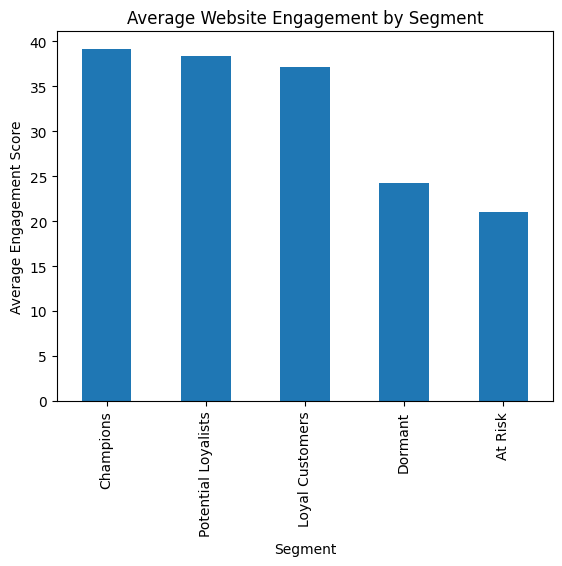

In [38]:
segment_engagement = (
    rfm.groupby('segment_name')['engagement_score']
    .mean()
    .sort_values(ascending=False)
)

segment_engagement.plot(kind='bar')

plt.title('Average Website Engagement by Segment')
plt.ylabel('Average Engagement Score')
plt.xlabel('Segment')

plt.show()

# Website Engagement Insights
The engagement analysis shows a clear relationship between customer segments and website activity. Champions and Loyal Customers demonstrate the highest engagement levels, while Dormant and At Risk customers exhibit significantly lower activity. This suggests that behavioural engagement is an important indicator of customer value and retention potential.

In [39]:
tickets = pd.read_csv("support_tickets.csv")
print(tickets.columns.tolist())

['ticket_id', 'customer_id', 'ticket_date', 'issue_type', 'support_channel', 'resolution_hours', 'sentiment_score', 'reopened']


In [40]:
ticket_summary = tickets.groupby('customer_id').agg(
    ticket_count=('ticket_id', 'count'),
    avg_sentiment=('sentiment_score', 'mean'),
    reopened_count=('reopened', 'sum')
).reset_index()

ticket_summary.head()

,customer_id,ticket_count,avg_sentiment,reopened_count
0,CUST00001,2,0.14,0
1,CUST00002,1,0.00,0
2,CUST00005,1,-1.00,0
3,CUST00006,2,-0.68,1
4,CUST00008,1,0.08,0


In [41]:
rfm = rfm.merge(ticket_summary, on='customer_id', how='left')

rfm['ticket_count'] = rfm['ticket_count'].fillna(0)
rfm['avg_sentiment'] = rfm['avg_sentiment'].fillna(0)
rfm['reopened_count'] = rfm['reopened_count'].fillna(0)

rfm.head()

,customer_id,Recency,Frequency,Monetary,R_score,F_score,M_score,segment_name,engagement_score,ticket_count,avg_sentiment,reopened_count
0,CUST00001,168,6,2955.57,2,4,3,At Risk,5,2.0,0.14,0.0
1,CUST00002,35,3,1713.10,4,2,2,Potential Loyalists,45,1.0,0.00,0.0
2,CUST00003,232,1,649.98,1,1,1,Dormant,4,0.0,0.00,0.0
3,CUST00004,192,1,1604.04,2,1,2,Dormant,7,0.0,0.00,0.0
4,CUST00005,11,6,3910.43,5,4,4,Champions,118,1.0,-1.00,0.0


# Support Ticket Insights
To strengthen the segmentation strategy, support ticket behaviour was included as an additional signal. Customers with frequent support interactions, repeated complaints, or negative sentiment may require different retention approaches compared to customers who simply purchase less frequently.
The analysis below examines how support activity varies across customer segments.

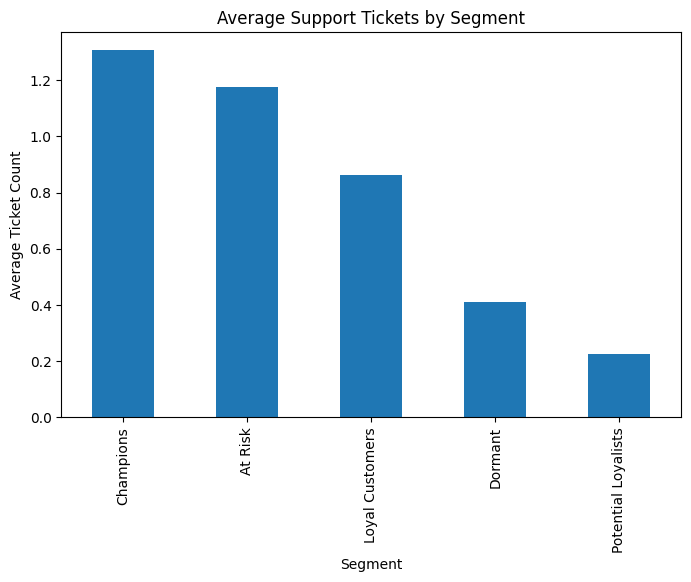

In [42]:
support_segment = rfm.groupby('segment_name')['ticket_count'].mean().sort_values(ascending=False)

plt.figure(figsize=(8,5))
support_segment.plot(kind='bar')
plt.title('Average Support Tickets by Segment')
plt.ylabel('Average Ticket Count')
plt.xlabel('Segment')
plt.show()

# Support Ticket Insights
The support ticket analysis highlights meaningful differences across customer segments. Champions and At Risk customers recorded the highest average number of support interactions, suggesting that support activity alone does not necessarily indicate low customer value. In the case of Champions, higher ticket volume may reflect greater product usage and engagement. For At Risk customers, frequent support interactions could indicate unresolved concerns or dissatisfaction.
Potential Loyalists showed the lowest ticket activity, while Dormant customers demonstrated limited engagement across both support and purchasing behaviour. These findings suggest that support history can provide additional context when prioritizing retention actions and customer outreach efforts.

#Retention Strategy Recommendations

Segment: Champions
Recommended Actions: Early access to new products and loyalty rewards
Business Reason: High-value customers should be retained through recognition rather than discounts

Segment: Loyal Customers
Recommended Actions: Personalized recommendations and cross-sell campaigns
Business Reason: Strong engagement indicates opportunity for additional purchases

Segment: Potential Loyalists
Recommended Action: Welcome offers and targeted nurturing campaigns
Business Reason: These customers show growth potential and can be converted into loyal buyers

Segment: At Risk
Recommended Action: Priority retention outreach and customer support follow-up
Business Reason: High churn risk requires immediate intervention

Segment: Dormant
Recommended Action: Reactivation campaigns with limited-time incentives
Business Reason: Low engagement customers require re-engagement efforts

# Budget Prioritization

Given a limited retention budget, I would prioritize the At Risk segment first. These customers have previously demonstrated purchasing behaviour but show signs of declining engagement and potential churn. Retaining an existing customer is generally more cost-effective than acquiring a new one.
The second priority would be Potential Loyalists because they represent customers who are close to becoming long-term valuable customers. Champions and Loyal Customers would receive lower-cost loyalty initiatives rather than aggressive retention spending. Dormant customers would receive only low-cost reactivation campaigns due to their uncertain recovery potential.

In [43]:
segments = rfm[['customer_id','segment_name','Recency','Frequency','Monetary',
                'engagement_score','ticket_count']]

segments.to_csv('segments.csv', index=False)

segments.head()

,customer_id,segment_name,Recency,Frequency,Monetary,engagement_score,ticket_count
0,CUST00001,At Risk,168,6,2955.57,5,2.0
1,CUST00002,Potential Loyalists,35,3,1713.10,45,1.0
2,CUST00003,Dormant,232,1,649.98,4,0.0
3,CUST00004,Dormant,192,1,1604.04,7,0.0
4,CUST00005,Champions,11,6,3910.43,118,1.0


In [44]:
from google.colab import files

files.download('segments.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Manual Review Cases
Some customers fall into situations where automated segmentation alone may not provide sufficient context for decision-making. A manual review was performed to identify customers whose retention actions should be validated before campaign execution.

In [45]:
manual_review = rfm.sort_values(
    ['engagement_score','ticket_count'],
    ascending=[False, False]
).head(10)

manual_review[['customer_id',
               'segment_name',
               'Recency',
               'Frequency',
               'Monetary',
               'engagement_score',
               'ticket_count']]

,customer_id,segment_name,Recency,Frequency,Monetary,engagement_score,ticket_count
629,CUST00630,Loyal Customers,54,4,3090.95,146,0.0
970,CUST00971,Champions,39,9,5971.94,145,1.0
1024,CUST01025,Champions,24,6,7672.87,143,2.0
658,CUST00659,Potential Loyalists,22,3,1580.63,137,0.0
1972,CUST01973,Loyal Customers,14,4,3552.32,135,0.0
1694,CUST01695,Loyal Customers,39,5,2439.20,133,1.0
1568,CUST01569,Champions,17,6,4032.73,133,0.0
1663,CUST01664,At Risk,136,3,2080.54,132,1.0
1131,CUST01132,Loyal Customers,58,7,6032.48,131,0.0
1508,CUST01509,Loyal Customers,40,5,2921.37,126,2.0


# Manual Review Cases

CUST00630 (Loyal Customers)
This customer shows very high engagement despite only moderate purchase frequency. I would target them with personalized product recommendations and loyalty rewards.

CUST00971 (Champions)
This customer has high spending levels and strong engagement. Maintaining VIP treatment and early access campaigns would help preserve loyalty.

CUST01025 (Champions)
This is one of the highest-value customers in the dataset. Premium loyalty benefits should be provided to reduce the risk of future churn.

CUST00659 (Potential Loyalists)
The customer is highly engaged but purchases less frequently than Champions. Targeted offers may help increase repeat purchases.

CUST01973 (Loyal Customers)
This customer demonstrates stable purchasing behaviour and strong engagement. Cross-selling related products could increase customer value.

CUST01695 (Loyal Customers)
Good engagement levels combined with occasional support interactions suggest a generally satisfied customer. Continued personalized communication is recommended.

CUST01569 (Champions)
A valuable customer with strong activity across multiple indicators. This customer should be included in premium retention programs.

CUST01664 (At Risk)
Although engagement remains relatively high, the long recency period indicates possible churn risk. A manual review and proactive outreach should be performed.

CUST01132 (Loyal Customers)
Strong monetary value and engagement make this customer an important retention target. Loyalty incentives would be appropriate.

CUST01509 (Loyal Customers)
This customer remains active and continues to engage with the business. Personalized retention campaigns should be maintained.

# Conclusion
This RFM segmentation analysis divided customers into five meaningful groups based on purchasing behaviour, customer value, and engagement signals. In addition to traditional RFM metrics, website activity and support ticket information were incorporated to provide a broader view of customer behaviour.

The results indicate that Champions and Loyal Customers represent the most valuable customer groups and should be retained through
loyalty-focused initiatives rather than excessive discounting.

Potential Loyalists demonstrate strong growth potential and should be nurtured through targeted engagement campaigns. The At Risk segment requires immediate attention due to declining purchasing behaviour, while Dormant customers are suitable candidates for low-cost reactivation efforts.

By combining transaction history with behavioural and support-related signals, the segmentation framework provides actionable guidance for customer retention planning and resource allocation.

In [46]:
rfm[['customer_id',
     'segment_name',
     'Recency',
     'Frequency',
     'Monetary',
     'engagement_score',
     'ticket_count']].to_csv('segments.csv', index=False)

print("segments.csv saved successfully")

segments.csv saved successfully
